# Global Solution — Modelagem Linear para Aprendizagem de Máquina
## Análise Estatística da Nova Economia Espacial

**Base:** Space Missions (1957–2022) — fonte: Next Spaceflight / Maven Analytics (dados reais).

**Integrantes:** _[PREENCHER NOME(S) E MATRÍCULA(S)]_

Este notebook cobre os itens 01 a 04 do briefing: seleção/justificativa da base,
tabelas de distribuição de frequências, gráficos e análises univariadas.

### 0. Importação de bibliotecas e configurações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
AZUL_PROFUNDO="#0B3D91"; LARANJA="#FC3D21"; AZUL_CLARO="#4C9BE8"
CINZA="#5A6472"; VERDE="#2BB673" 

## 1. Seleção e justificativa da base de dados
A base *Space Missions (1957–2022)* reúne dados **reais** de praticamente todas as
missões espaciais da história (organização, local, data, foguete, custo e status).
Justifica-se pela **relevância** ao tema da nova economia espacial, **volume** (4.630
registros / 66 anos), **qualidade/estrutura** dos campos e **potencial analítico**
(variáveis discretas, contínuas e categóricas).

In [2]:
df = pd.read_csv("../dados/space_missions.csv", encoding="utf-8")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Ano"] = df["Date"].dt.year
df["Custo"] = pd.to_numeric(df["Price"].astype(str).str.replace(",", "", regex=False), errors="coerce")
df["Pais"] = df["Location"].str.split(", ").str[-1].str.strip()
print("Registros:", len(df), "| Período:", int(df.Ano.min()), "-", int(df.Ano.max()))
df.head()

Registros: 4630 | Período: 1957 - 2022


,Company,Location,Date,Time,Rocket,Mission,RocketStatus,Price,MissionStatus,Ano,Custo,Pais
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-10-04,19:28:00,Sputnik 8K71PS,Sputnik-1,Retired,NaN,Success,1957,NaN,Kazakhstan
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03,02:30:00,Sputnik 8K71PS,Sputnik-2,Retired,NaN,Success,1957,NaN,Kazakhstan
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06,16:44:00,Vanguard,Vanguard TV3,Retired,NaN,Failure,1957,NaN,USA
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01,03:48:00,Juno I,Explorer 1,Retired,NaN,Success,1958,NaN,USA
4,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05,07:33:00,Vanguard,Vanguard TV3BU,Retired,NaN,Failure,1958,NaN,USA


## 2. Tabelas de Distribuição de Frequências
### 2.1 Variável quantitativa DISCRETA — Lançamentos por ano

In [3]:
cont = df["Ano"].dropna().astype(int).value_counts().sort_index()
n = cont.sum()
fdt_disc = pd.DataFrame({"Ano": cont.index, "fi": cont.values})
fdt_disc["fr_%"] = (fdt_disc.fi/n*100).round(2)
fdt_disc["Fi"] = fdt_disc.fi.cumsum()
fdt_disc["Fr_%"] = (fdt_disc.Fi/n*100).round(2)
fdt_disc.head(10)

,Ano,fi,fr_%,Fi,Fr_%
0,1957,3,0.06,3,0.06
1,1958,28,0.60,31,0.67
2,1959,20,0.43,51,1.10
3,1960,39,0.84,90,1.94
4,1961,52,1.12,142,3.07
5,1962,82,1.77,224,4.84
6,1963,41,0.89,265,5.72
7,1964,60,1.30,325,7.02
8,1965,87,1.88,412,8.90
9,1966,101,2.18,513,11.08


### 2.2 Variável quantitativa CONTÍNUA — Custo do foguete (US$ milhões)

In [4]:
serie = df["Custo"].dropna()
n = len(serie)
k_sturges = int(round(1 + 3.322*np.log10(n)))
print("Sturges sugere k =", k_sturges, "classes (n =", n, ")")
limites = [0,25,50,100,200,500,1000, serie.max()]
rot, fis, pm = [], [], []
for i in range(len(limites)-1):
    li, ls = limites[i], limites[i+1]
    mask = (serie>=li)&(serie<ls) if i<len(limites)-2 else (serie>=li)&(serie<=ls)
    fechado = ")" if i<len(limites)-2 else "]"
    rot.append(f"[{li:.0f} ; {ls:.0f}{fechado}"); fis.append(int(mask.sum())); pm.append((li+ls)/2)
fdt_cont = pd.DataFrame({"Classe (US$ mi)":rot,"Ponto médio":pm,"fi":fis})
fdt_cont["fr_%"]=(fdt_cont.fi/n*100).round(2)
fdt_cont["Fi"]=fdt_cont.fi.cumsum()
fdt_cont["Fr_%"]=(fdt_cont.Fi/n*100).round(2)
fdt_cont

Sturges sugere k = 11 classes (n = 1265 )


,Classe (US$ mi),Ponto médio,fi,fr_%,Fi,Fr_%
0,[0 ; 25),12.5,144,11.38,144,11.38
1,[25 ; 50),37.5,404,31.94,548,43.32
2,[50 ; 100),75.0,344,27.19,892,70.51
3,[100 ; 200),150.0,129,10.20,1021,80.71
4,[200 ; 500),350.0,229,18.10,1250,98.81
5,[500 ; 1000),750.0,0,0.00,1250,98.81
6,[1000 ; 5000],3000.0,15,1.19,1265,100.00


## 3. Gráficos estatísticos
### 3.1 Histograma do custo dos foguetes (variável contínua)

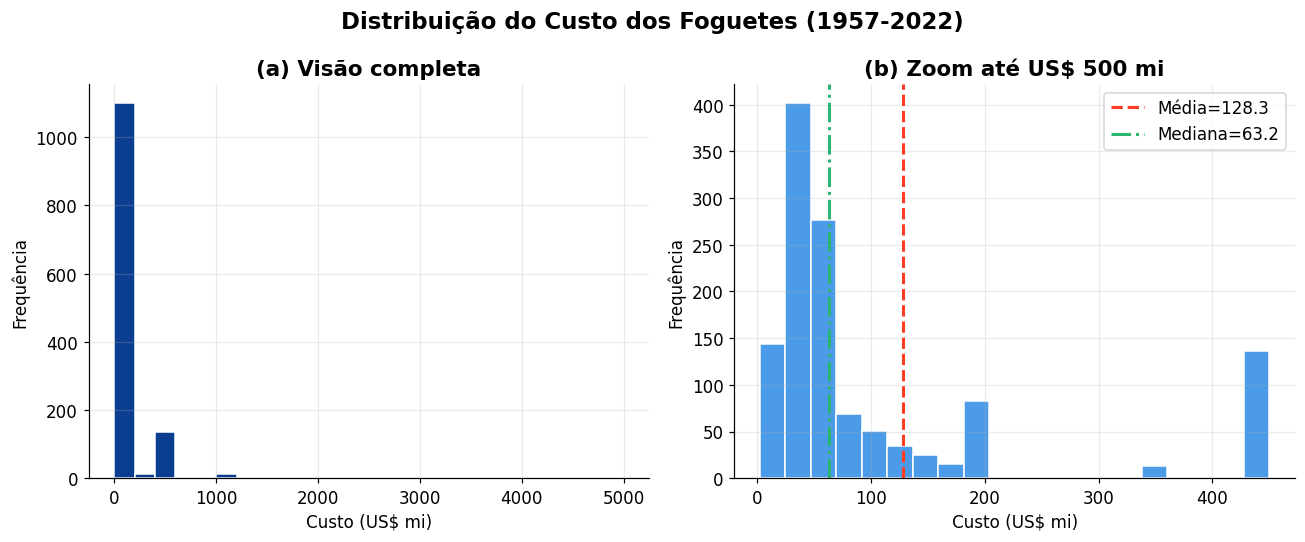

In [5]:
custo = df["Custo"].dropna()
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
a1.hist(custo,bins=25,color=AZUL_PROFUNDO,edgecolor="white"); a1.set_title("(a) Visão completa")
a1.set_xlabel("Custo (US$ mi)"); a1.set_ylabel("Frequência")
foco=custo[custo<=500]
a2.hist(foco,bins=20,color=AZUL_CLARO,edgecolor="white")
a2.axvline(custo.mean(),color=LARANJA,ls="--",lw=2,label=f"Média={custo.mean():.1f}")
a2.axvline(custo.median(),color=VERDE,ls="-.",lw=2,label=f"Mediana={custo.median():.1f}")
a2.set_title("(b) Zoom até US$ 500 mi"); a2.set_xlabel("Custo (US$ mi)"); a2.set_ylabel("Frequência"); a2.legend()
fig.suptitle("Distribuição do Custo dos Foguetes (1957-2022)",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()

### 3.2 Evolução do número de lançamentos por ano (variável temporal)

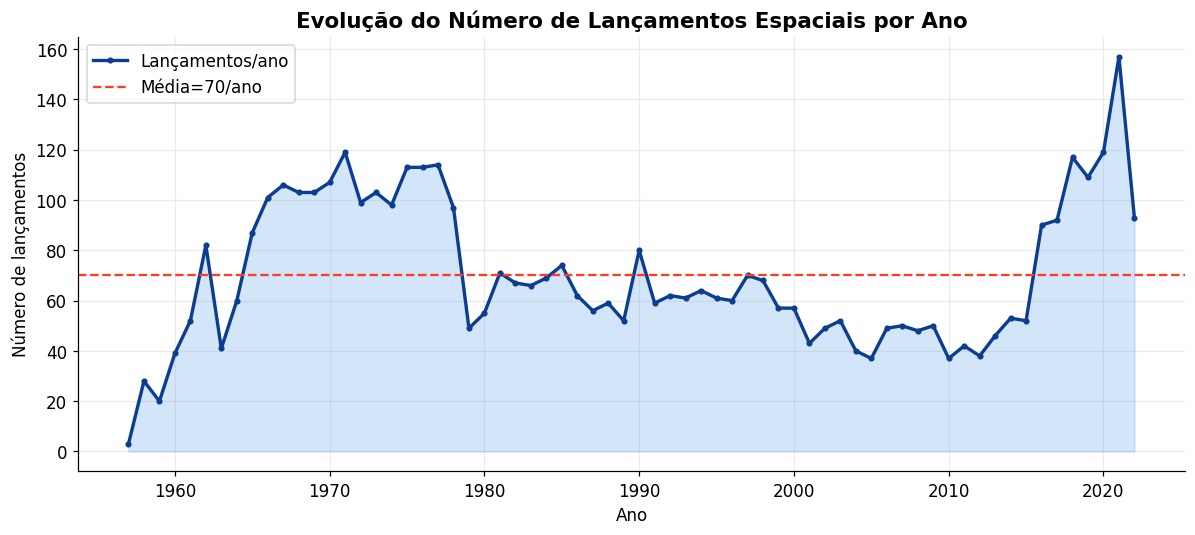

In [6]:
lpa = df.groupby("Ano").size()
plt.figure(figsize=(11,5))
plt.plot(lpa.index,lpa.values,color=AZUL_PROFUNDO,lw=2.2,marker="o",ms=3,label="Lançamentos/ano")
plt.fill_between(lpa.index,lpa.values,color=AZUL_CLARO,alpha=0.25)
plt.axhline(lpa.mean(),color=LARANJA,ls="--",label=f"Média={lpa.mean():.0f}/ano")
plt.title("Evolução do Número de Lançamentos Espaciais por Ano")
plt.xlabel("Ano"); plt.ylabel("Número de lançamentos"); plt.legend(); plt.tight_layout(); plt.show()

## 4. Análises univariadas (Estatística Descritiva)

In [7]:
def descritiva(s, nome):
    s = s.dropna().astype(float)
    print(f"\n===== {nome} (n={int(s.count())}) =====")
    print(f"Média: {s.mean():.2f} | Mediana: {s.median():.2f} | Moda: {', '.join(f'{x:.2f}' for x in s.mode())}")
    print(f"Máx: {s.max():.2f} | Mín: {s.min():.2f} | Amplitude: {s.max()-s.min():.2f}")
    print(f"Variância: {s.var(ddof=1):.2f} | Desvio padrão: {s.std(ddof=1):.2f} | CV: {s.std(ddof=1)/s.mean()*100:.2f}%")
    print(f"Q1: {s.quantile(.25):.2f} | Q2: {s.quantile(.5):.2f} | Q3: {s.quantile(.75):.2f} | IQR: {s.quantile(.75)-s.quantile(.25):.2f}")

descritiva(df["Custo"], "Custo do foguete (US$ mi)")
descritiva(df.groupby("Ano").size(), "Lançamentos por ano")


===== Custo do foguete (US$ mi) (n=1265) =====
Média: 128.30 | Mediana: 63.23 | Moda: 450.00
Máx: 5000.00 | Mín: 2.50 | Amplitude: 4997.50
Variância: 65930.66 | Desvio padrão: 256.77 | CV: 200.13%
Q1: 30.00 | Q2: 63.23 | Q3: 115.00 | IQR: 85.00

===== Lançamentos por ano (n=66) =====
Média: 70.15 | Mediana: 61.50 | Moda: 52.00
Máx: 157.00 | Mín: 3.00 | Amplitude: 154.00
Variância: 852.90 | Desvio padrão: 29.20 | CV: 41.63%
Q1: 50.00 | Q2: 61.50 | Q3: 96.00 | IQR: 46.00


### Interpretação
- **Custo:** média (128,3) >> mediana (63,2) → distribuição **assimétrica à direita**; a mediana
  representa melhor o custo típico. CV de 200% indica dispersão altíssima (de pequenos lançadores a megaprogramas).
- **Lançamentos/ano:** média ≈ mediana (≈ 65–70) → distribuição mais simétrica; amplitude de 3 (1957)
  a 157 (2021) reflete os ciclos do setor e o atual reaquecimento da nova economia espacial.

> O relatório técnico completo (PDF), com conclusões e recomendações ao cliente, está no repositório.